# Detect objects in the environment and track them in 3D, even under occlusions

In [22]:
import glob
import os

import cv2
import numpy as np
from matplotlib import pyplot as plt
from ultralytics import YOLO
import math

# Load the sequences

In [23]:
sequence_num = 2

In [24]:
sequence = '34759_final_project_rect/'
calib_file_path = os.path.join(sequence, 'calib_cam_to_cam.txt')

left_cam_dir = os.path.join(sequence, f'seq_0{sequence_num}/image_02/data/')
left_cam = sorted(glob.glob(os.path.join(left_cam_dir, '*')))

right_cam_dir = os.path.join(sequence, f'seq_0{sequence_num}/image_03/data/')
right_cam = sorted(glob.glob(os.path.join(right_cam_dir, '*')))

# Visualize a sample from sequence

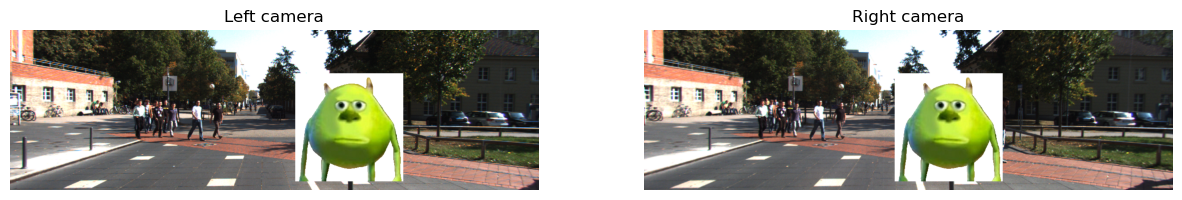

In [25]:
left_image_sample = cv2.imread(left_cam[50])
right_image_sample = cv2.imread(right_cam[50])

left_image_sample = cv2.cvtColor(left_image_sample, cv2.COLOR_BGR2RGB)
right_image_sample = cv2.cvtColor(right_image_sample, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].imshow(left_image_sample)
axes[0].set_title("Left camera")
axes[0].axis('off')

axes[1].imshow(right_image_sample)
axes[1].set_title("Right camera")
axes[1].axis('off')
plt.show()

# Helper functions

### Output to ply

In [26]:
ply_header = '''ply
format ascii 1.0
element vertex %(vert_num)d
property float x
property float y
property float z
property uchar red
property uchar green
property uchar blue
end_header
'''


def write_ply(fn, verts, colors):
    verts = verts.reshape(-1, 3)
    colors = colors.reshape(-1, 3)
    verts = np.hstack([verts, colors])
    with open(fn, 'wb') as f:
        f.write((ply_header % dict(vert_num=len(verts))).encode('utf-8'))
        np.savetxt(f, verts, fmt='%f %f %f %d %d %d ')

### Parse `calib_cam_to_cam.txt` for projection matrix

In [27]:
with open(calib_file_path, 'r') as f:
    calibration = {}
    for line in f.readlines():
        try:
            key, values_str = line.split(':')
            key = key.strip()
            values = np.array([float(x) for x in values_str.split()])

            if key in ['P_rect_02', 'P_rect_03']:
                calibration[key] = values.reshape((3, 4))

            elif key in ['S_rect_02', 'S_rect_03']:
                calibration[key] = values.astype(int)
            else:
                calibration[key] = values
        except ValueError:
            continue

# Stereo matching

In [28]:
min_disp = 0
num_disp = 6 * 16
block_size = 7  # ODD integer

P1 = 8 * block_size ** 2
P2 = 32 * block_size ** 2

In [29]:
stereo = cv2.StereoSGBM_create(
    minDisparity=min_disp,
    numDisparities=num_disp,
    blockSize=block_size,
    P1=P1,
    P2=P2,
    disp12MaxDiff=1,
    uniquenessRatio=10,
    speckleWindowSize=100,
    speckleRange=32,
    mode=cv2.STEREO_SGBM_MODE_SGBM
)

### Try a frame from cam_02 and cam_03

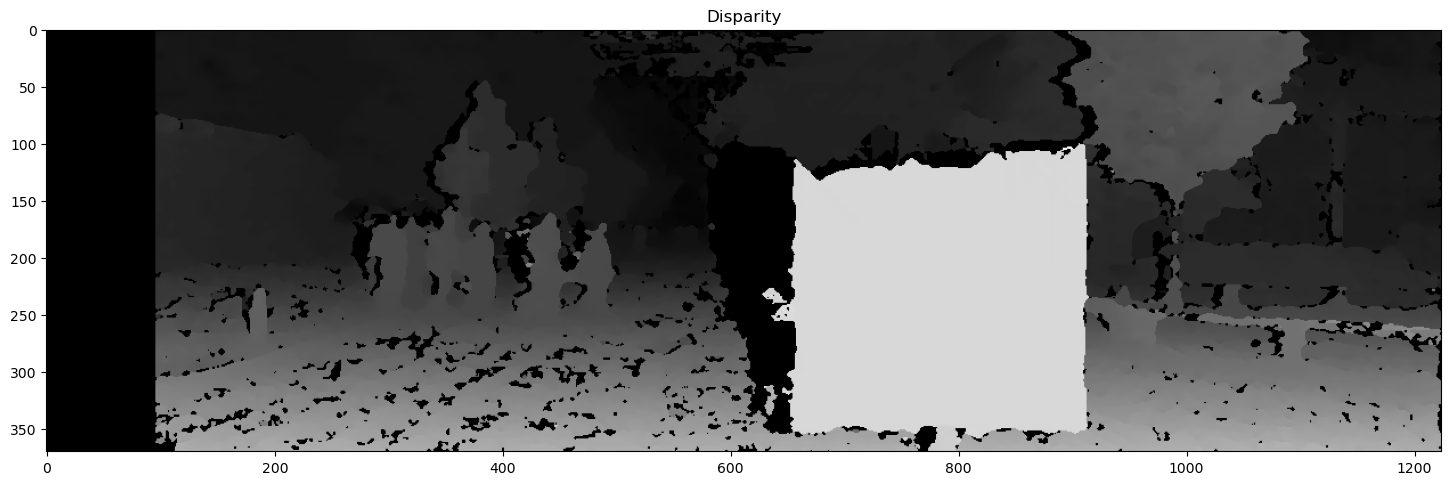

In [30]:
img_left_path_sample = left_cam[51]
img_right_path_sample = right_cam[51]

img_left_sample = cv2.imread(img_left_path_sample, cv2.IMREAD_GRAYSCALE)
img_right_sample = cv2.imread(img_right_path_sample, cv2.IMREAD_GRAYSCALE)

disp = stereo.compute(img_left_sample, img_right_sample).astype(np.float32) / 16.0

plt.figure(figsize=(18, 18))
plt.imshow(disp, cmap='gray')
plt.title("Disparity")
plt.show()

# Projection matrix from `calib_cam_to_cam.txt`

In [11]:
P_rect_02 = calibration['P_rect_02']
P_rect_03 = calibration['P_rect_03']

# Focal length, fx == fy == f
fx = P_rect_02[0, 0]
fy = P_rect_02[1, 1]

# Principal point x and y
cx = P_rect_02[0, 2]
cy = P_rect_02[1, 2]

# Baseline term from the car image
Tx = 0.54

### Q matrix for reprojection
https://docs.carnegierobotics.com/docs/cookbook/overview.html

In [12]:
Q = np.float32([
    [1, 0, 0, -cx],
    [0, 1, 0, -cy],
    [0, 0, 0, fx],
    [0, 0, 1 / Tx, 0]
])

In [13]:
points_3D = cv2.reprojectImageTo3D(disp, Q)

img_left_color_sample = cv2.cvtColor(img_left_sample, cv2.COLOR_BGR2RGB)

mask = disp > disp.min()
out_points = points_3D[mask]
out_colors = img_left_color_sample[mask]

write_ply('sample_out.ply', out_points, out_colors)

## YOLO

| Class   | Class ID (COCO) |
|---------|-----------------|
| Person  | 0               |
| Bicycle | 1               |
| Car     | 2               |


In [14]:
model = YOLO('../yolov8n.pt')
model_names = model.names
TARGET_CLASSES = [0, 1, 2]
yolo_color = (255, 0, 0)
kalman_color = (0, 255, 0)
video = []

In [15]:
final_tracks_3d = {}
kalman_filters = {}
num_frames = len(min(left_cam, right_cam))

# Kalman Filter
https://www.geeksforgeeks.org/python/kalman-filter-in-python/

In [16]:
class KalmanFilter:
    def __init__(self, F, B, H, Q, R, x0, P0):
        self.F = F
        self.B = B
        self.H = H
        self.Q = Q
        self.R = R
        self.x = x0
        self.P = P0

    def predict(self, u):
        self.x = np.dot(self.F, self.x) + np.dot(self.B, u)
        self.P = np.dot(self.F, np.dot(self.P, self.F.T)) + self.Q
        return self.x

    def update(self, z):
        S = np.dot(self.H, np.dot(self.P, self.H.T)) + self.R
        K = np.dot(np.dot(self.P, self.H.T), np.linalg.inv(S))
        y = z - np.dot(self.H, self.x)
        self.x = self.x + np.dot(K, y)
        I = np.eye(self.P.shape[0])
        self.P = np.dot(I - np.dot(K, self.H), self.P)
        return self.x


### Time between each frame
### Its roughly every 0.1 seconds, there is a new frame

### `timestamps.txt` from `seq_01/`

```
2011-09-28 12:50:11.645911040
2011-09-28 12:50:11.749547008
```

In [17]:
k = 0.1 # size of each step (should be eaqual to framerate)

### State Transition Matrix

In [18]:
F = np.array([
    [1, 0, 0, k, 0, 0],
    [0, 1, 0, 0, k, 0],
    [0, 0, 1, 0, 0, k],
    [0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 1],
])

### Observation Matrix (Only the position is measured)

In [19]:
H = np.array([
    [1, 0, 0, 0, 0, 0],   # measure X
    [0, 1, 0, 0, 0, 0],   # measure Y
    [0, 0, 1, 0, 0, 0],   # measure Z
])

### Control matrices

In [20]:
B = np.zeros((6, 1))
u = np.zeros((1, 1))

### Measurement noise

In [21]:
# Measurement noise: std ≈ 0.5 m in each dim (tune this)
sigma_meas = 0.5
R = np.eye(3) * (sigma_meas ** 2)

### Initial Covariance

In [22]:
# Initial covariance
pos_var = 1.0     # 1 m^2
vel_var = 10.0    # (m/s)^2

P0 = np.eye(6)

P0[0, 0] = pos_var
P0[1, 1] = pos_var
P0[2, 2] = pos_var

P0[3, 3] = vel_var
P0[4, 4] = vel_var
P0[5, 5] = vel_var

### Kalman process Noise

In [23]:
# Process noise, 1D constant-velocity (pos/vel) block
q_mag = 0.25  # scales the noise level

# Noise matrix fro 1d motion
Q_1D = np.array([
    [k**4 / 4.0, k**3 / 2.0],
    [k**3 / 2.0, k**2       ]
]) * q_mag

# Build 3D block-diagonal Q for [X,Y,Z,Vx,Vy,Vz]
Q_kf = np.zeros((6, 6))

for pos_idx, vel_idx in [(0, 3), (1, 4), (2, 5)]:
    Q_kf[pos_idx, pos_idx] = Q_1D[0, 0]
    Q_kf[pos_idx, vel_idx] = Q_1D[0, 1]
    Q_kf[vel_idx, pos_idx] = Q_1D[1, 0]
    Q_kf[vel_idx, vel_idx] = Q_1D[1, 1]

In [24]:
def initialize_kf(point_3d):
    x, y, z = point_3d
    x0 = np.array([[x], [y], [z], [0.0], [0.0], [0.0]])  # zero initial velocity
    return KalmanFilter(
        F=F,
        B=B,
        H=H,
        Q=Q_kf,
        R=R,
        x0=x0,
        P0=P0.copy(),
    )

## 3D localization
### Given a 2D bounding box of an object, it extracts that section from the disparity map, and takes the median disparity within this section to give the entire object detected by YOLO a depth.

In [25]:
def get_3d_coordinates(bbox_2d, disp_map):
    x1, y1, x2, y2 = bbox_2d
    box_disp = disp_map[y1:y2, x1:x2]

    valid_disps = box_disp[box_disp > 0]

    if len(valid_disps) < 5:
        return None

    median_disp = np.median(valid_disps)

    center_u = int((x1 + x2) / 2)
    center_v = int((y1 + y2) / 2)

    Z = (fx * Tx) / median_disp  # This is the depth calculation
    X = (center_u - cx) * Z / fx
    Y = (center_v - cy) * Z / fy

    return X, Y, Z


### Helper functions for 'Main Sequence' loop

In [26]:
def yolo_track(left, right):
    img_left_gray = cv2.imread(left, cv2.IMREAD_GRAYSCALE)
    img_right_gray = cv2.imread(right, cv2.IMREAD_GRAYSCALE)
    img_left_color = cv2.imread(left)

    disp = stereo.compute(img_left_gray, img_right_gray).astype(np.float32) / 16.0

    # 2D Detection and Tracking with YOLO
    track_results = model.track(img_left_color,
                                persist=True,
                                verbose=False,
                                classes=TARGET_CLASSES)

    return track_results[0].boxes, disp

# Project 3D camera coordinates (X,Y,Z) to pixel coords (u,v).
def project_3d_to_2d(X, Y, Z, fx, fy, cx, cy):
    if Z <= 0:
        return None  # invalid / behind camera
    u = fx * X / Z + cx
    v = fy * Y / Z + cy
    return int(u), int(v)

def annotate_frame(frame, bbox, points_3d, track_id, lost=False):

    x1, y1, x2, y2 = bbox
    X, Y, Z = points_3d

    # Yellow if lost, else green
    color = (0, 255, 0) if not lost else (0, 255, 255)

    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
    
    label = f"ID {track_id}" if not lost else f"ID {track_id} (lost)"
    cv2.putText(
        frame, label, 
        (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1
    )

    # 3D text position below box
    text = f"X:{X:.2f} Y:{Y:.2f} Z:{Z:.2f} m"
    cv2.putText(
        frame, text, 
        (x1, y2 + 15), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1
    )
    return frame

def bbox_center_2d(box):
    x1, y1, x2, y2 = box
    return (x1 + x2) / 2.0, (y1 + y2) / 2.0


def greedy_association_3d(tracks, det_points, det_classes, gate_ped, gate_car):
    
    track_ids = list(tracks.keys())

    # All start as unmatched
    unmatched_tracks = set(track_ids)
    unmatched_dets = set(range(len(det_points)))

    # Best matches
    matches = []

    # Store every valid match based on Gate dist before picking closest one
    candidates = []
    for tid in track_ids:
        Xp, Yp, Zp = tracks[tid]["pred_pos"]    # predicted position

        for j, p in enumerate(det_points):
            Xd, Yd, Zd = p                      # detected position

            # Choose gate distance based on class
            class_id = det_classes[j]

            if class_id == 0:  # pedestrian
                gate = gate_ped
            else:              # car / vehicle class
                gate = gate_car

            # Eucledian dist in 3D
            dist = math.sqrt((Xp - Xd)**2 + (Yp - Yd)**2 + (Zp - Zd)**2)

            if dist < gate:
                candidates.append((dist, tid, j))

    candidates.sort(key=lambda x: x[0]) # Sort for shortest dist first

    for dist, tid, j in candidates:
        if tid in unmatched_tracks and j in unmatched_dets: # match if both track id and detections are still free
            matches.append((tid, j))
            unmatched_tracks.remove(tid)
            unmatched_dets.remove(j)

    return matches, unmatched_tracks, unmatched_dets

## Main sequence

In [27]:
#GATE_DIST_3D = 3.5  # max distance in 3D for what can be the same person
MAX_MISSED = 50     # If a track is lost for more than 50 frames we delete

GATE_DIST_3D_PED = 1.5
GATE_DIST_3D_CAR = 6.5

# dictionary to keep track of kalman filter, last bbox, 
# predicted bbox and number of missed matched (occluded frames)
tracks = {}        
next_track_id = 0

for i in range(num_frames):
    img_left_path = left_cam[i]
    img_right_path = right_cam[i]

    annotation_frame = cv2.imread(img_left_path)
    result_boxes, disp = yolo_track(img_left_path, img_right_path)

    # We do kalman filter prediction for the resluting tracks
    for tid, trk in tracks.items():
        x_pred = trk["kf"].predict(u)   
        pred_pos = x_pred[:3, 0]        
        trk["pred_pos"] = pred_pos      

    detections_2d = []      
    detections_3d = []      
    det_classes = []        

    if result_boxes is not None and len(result_boxes) > 0:
        boxes = result_boxes.xyxy.int().cpu().tolist()
        classes = result_boxes.cls.int().cpu().tolist()

        for box, class_id in zip(boxes, classes):
            x1, y1, x2, y2 = box
            bbox_2d = (x1, y1, x2, y2)
            point_3d = get_3d_coordinates(bbox_2d, disp)

            if point_3d is None:
                continue        # Less than 5 valid disparities, we don't trust 

            if class_id == 0 or class_id == 1: # or class_id == 2: # Unncomment this to track cars
                detections_2d.append(bbox_2d)
                detections_3d.append(np.array(point_3d))
                det_classes.append(class_id)

    # Associates detections to existing tracks in 3D
    if len(tracks) > 0 and len(detections_3d) > 0:
        matches, unmatched_tracks, unmatched_dets = greedy_association_3d(
            tracks, detections_3d, det_classes, GATE_DIST_3D_PED, GATE_DIST_3D_CAR
        )
    else:
        matches = []
        unmatched_tracks = set(tracks.keys())
        unmatched_dets = set(range(len(detections_3d)))

    # We update Kalman and draw green boxes when kalman prediction and yolo match
    for tid, det_idx in matches:
        trk = tracks[tid]
        bbox = detections_2d[det_idx]
        Xd, Yd, Zd = detections_3d[det_idx]
        class_id = det_classes[det_idx]

        # # If the detected box suddenly changes drastically in size
        # # 2x bigger or smaller, we set the current box as the last box
        # if trk["last_box"] is not None:
        #     x1_l, y1_l, x2_l, y2_l = trk["last_box"]
        #     w_l = x2_l - x1_l
        #     h_l = y2_l - y1_l

        #     x1_c, y1_c, x2_c, y2_c = bbox
        #     w_c = x2_c - x1_c
        #     h_c = y2_c - y1_c

        #     if w_c < w_l/2 or h_c < h_l/2 or w_c > 2*w_l or h_c > 2*h_l:
        #         cx, cy = (x1_c + x2_c)/2, (y1_c + y2_c)/2
        #         bbox = (
        #             int(cx - w_l/2),
        #             int(cy - h_l/2),
        #             int(cx + w_l/2),
        #             int(cy + h_l/2)
        #         )

        z = np.array([[Xd], [Yd], [Zd]])
        trk["kf"].update(z)
        trk["last_box"] = bbox
        trk["class_id"] = class_id
        trk["missed"] = 0


        Xf, Yf, Zf = trk["kf"].x[:3, 0]

        # draw GREEN bbox
        annotation_frame = annotate_frame(
            annotation_frame,
            bbox,
            (Xf, Yf, Zf),
            track_id=tid,
            lost=False
        )
    
    # We allow new track to be created for the first 3 frames of the video, after which, 
    # we freez the id's and tracks and only track those objects for the rest of the video.

    if i < 3:
        for det_idx in unmatched_dets:
            bbox = detections_2d[det_idx]
            Xd, Yd, Zd = detections_3d[det_idx]
            class_id = det_classes[det_idx]

            kf = initialize_kf((Xd, Yd, Zd))
            tid = next_track_id
            next_track_id += 1

            tracks[tid] = {
                "kf": kf,
                "last_box": bbox,
                "class_id": class_id,
                "missed": 0,
                "pred_pos": np.array([Xd, Yd, Zd]),
            }
            
            Xf, Yf, Zf = tracks[tid]["kf"].x[:3, 0]

            annotation_frame = annotate_frame(
                annotation_frame,
                bbox,
                (Xf, Yf, Zf),
                track_id=tid,
                lost=False
            )

    else:
        # We don't allow new tracks
        pass

    # Unmatched tracks, meaning occluded (or gone)
    tracks_to_delete = []
    for tid in unmatched_tracks:
        trk = tracks[tid]
        trk["missed"] = trk.get("missed", 0) + 1

        # We predict center position, so we use the bbox size from 
        # the last time we (Yolo) saw the person
        # last measured box size
        x1_m, y1_m, x2_m, y2_m = trk["last_box"]
        w = x2_m - x1_m
        h = y2_m - y1_m

        # predicted 3D
        Xp, Yp, Zp = trk["pred_pos"]

        img_h, img_w = annotation_frame.shape[:2]

        # project predicted 3D back to image to get predicted center
        uv = project_3d_to_2d(Xp, Yp, Zp, fx, fy, cx, cy)
        if uv is not None:
            u_pred, v_pred = uv

        
            # If person moves outside of the frame, we delete the track
            if not (0 <= u_pred < img_w) and not (0 <= v_pred < img_h):
                tracks_to_delete.append(tid)

            # build predicted 2D box with same size as last measurement
            x1 = int(u_pred - w / 2.0)
            y1 = int(v_pred - h / 2.0)
            x2 = int(u_pred + w / 2.0)
            y2 = int(v_pred + h / 2.0)

        else:
            # we juse last measured box as a fallback
            x1, y1, x2, y2 = x1_m, y1_m, x2_m, y2_m


        annotation_frame = annotate_frame(
            annotation_frame,
            (x1, y1, x2, y2),
            (Xp, Yp, Zp),
            track_id=tid,
            lost=True
        )

        if trk["missed"] > MAX_MISSED:
            tracks_to_delete.append(tid)

    for tid in tracks_to_delete:
        del tracks[tid]

    # Uncomment to show frames
    # plt.imshow(cv2.cvtColor(annotation_frame, cv2.COLOR_BGR2RGB))
    # plt.axis('off')
    # plt.pause(0.01)

    # Make vid
    video.append(annotation_frame) # Running this cell takes approx 1 minute

# Output to a video

In [28]:
frame_height, frame_width, _ = video[0].shape
video_filename = f'sequence_0{sequence_num}.mp4'

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = 10

out = cv2.VideoWriter(video_filename, fourcc, fps, (frame_width, frame_height))

for frame in video:
    out.write(frame)

out.release()